In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt 

### Step 1: Sanity check of the training for neural nets

We will first fetch some data from our dataset and use the `encoder_features` and `encoder_labels` net to check if the encoded image of a ring and the encoded labels are close in latent space (we can visualize it in 2d). 

In [3]:
from astro_peek import Encoder

def load_model(paths):
    model_list = []
    for path in tqdm(paths): 
        model_data = torch.load(path, map_location = "cpu")
        cfg = model_data['model_cfg']
        model = Encoder(cfg = cfg)
        model.load_state_dict(model_data["model"])
        model_list.append(model)
    return model_list

In [6]:
from glob import glob
from tqdm import tqdm 
from natsort import natsorted

EXPERIMENT="strong_lenses"
model_path = f"/home/noedia/scratch/crl/experiments/{EXPERIMENT}/models/"
encoders_features_dir = "encoder_features/"
encoders_labels_dir = "encoder_labels/"
pattern = "*.pt"

encoder_x_paths = natsorted(glob(model_path + encoders_features_dir + pattern))  
encoder_y_paths = natsorted(glob(model_path + encoders_labels_dir + pattern))

print("Loading the models for different random seeds ")
encoder_x_list = load_model(encoder_x_paths)
encoder_y_list = load_model(encoder_y_paths)

Loading the models for different random seeds 


100%|██████████| 5/5 [00:00<00:00,  5.68it/s]


In [24]:
encoder_x_paths

['/home/noedia/scratch/crl/experiments/strong_lenses/models/encoder_features/seed_40_latentdim_2.pt',
 '/home/noedia/scratch/crl/experiments/strong_lenses/models/encoder_features/seed_41_latentdim_2.pt',
 '/home/noedia/scratch/crl/experiments/strong_lenses/models/encoder_features/seed_42_latentdim_2.pt',
 '/home/noedia/scratch/crl/experiments/strong_lenses/models/encoder_features/seed_43_latentdim_2.pt',
 '/home/noedia/scratch/crl/experiments/strong_lenses/models/encoder_features/seed_44_latentdim_2.pt']

# Latent space visualization sanity check

(array([  61.,  354., 1113., 2353., 2835., 2104.,  899.,  244.,   34.,
           3.]),
 array([-0.16129286, -0.12465826, -0.08802365, -0.05138905, -0.01475445,
         0.02188016,  0.05851476,  0.09514936,  0.13178397,  0.16841857,
         0.20505318]),
 <BarContainer object of 10 artists>)

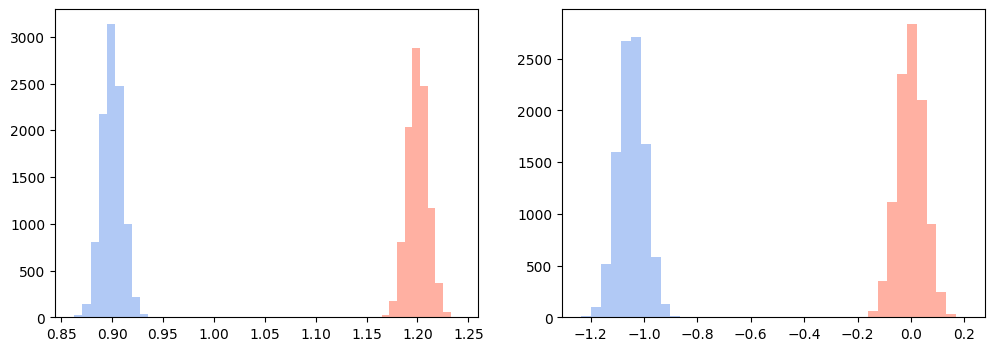

In [9]:
import numpy as np
def sample_prior(prior, size):
    return prior(size)

# prior_params_config = {
#         "einstein_radius": {"low": 0.8, "high": 1.5}, 
#         "phi": {"low": -np.pi/2, "high": np.pi/4}
#     }


# radius_prior = prior_params_config["einstein_radius"]
# phi_prior = prior_params_config["phi"]
# prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
# prior_sampler_phi = lambda size: np.random.uniform(phi_prior["low"], phi_prior["high"], size = size)

prior_radius_a = lambda size: np.random.normal(loc = 0.9, scale = 0.01, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 1.2, scale = 0.01, size = size)

prior_phi_a = lambda size: np.random.normal(loc = -np.pi/3, scale = 0.05, size = size)
prior_phi_b = lambda size: np.random.normal(loc = 0, scale = 0.05, size = size)


fig, axs = plt.subplots(1, 2, figsize = (12, 4))
ax = axs[0]
samples_a = sample_prior(prior_radius_a, size = 10_000)
samples_b = sample_prior(prior_radius_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)


ax = axs[1]
samples_a = sample_prior(prior_phi_a, size = 10_000)
samples_b = sample_prior(prior_phi_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)

In [13]:
from datasets import load_from_disk
from tqdm import tqdm
from astro_peek.datasets.make_rings import make_rings
from astro_peek.datasets.make_lenses import simulate_system


dataset_size = 1000

prior_radius_a = lambda size: np.random.normal(loc = 0.9, scale = 0.01, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 1.2, scale = 0.01, size = size)

prior_phi_a = lambda size: np.random.normal(loc = -np.pi/3, scale = 0.05, size = size)
prior_phi_b = lambda size: np.random.normal(loc = 0, scale = 0.05, size = size)

# Creating latent factors and normalizing them...
radius = np.concatenate([sample_prior(prior_radius_a, dataset_size), sample_prior(prior_radius_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(radius)

sigma = np.concatenate([sample_prior(prior_phi_a, dataset_size), sample_prior(prior_phi_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(sigma)

labels = np.concatenate([np.zeros(dataset_size), np.ones(dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(labels)

theta = np.stack([radius, sigma]).T

# Creating simulations from it 
images = []
for params in tqdm(theta): 
    image, _ = simulate_system(*params)
    images.append(image) 

images = np.array(images)
# radius = (radius - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"])
# sigma =  (sigma - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"])
theta = np.stack([radius, sigma]).T

100%|██████████| 2000/2000 [00:14<00:00, 133.84it/s]


Checking a few rings 

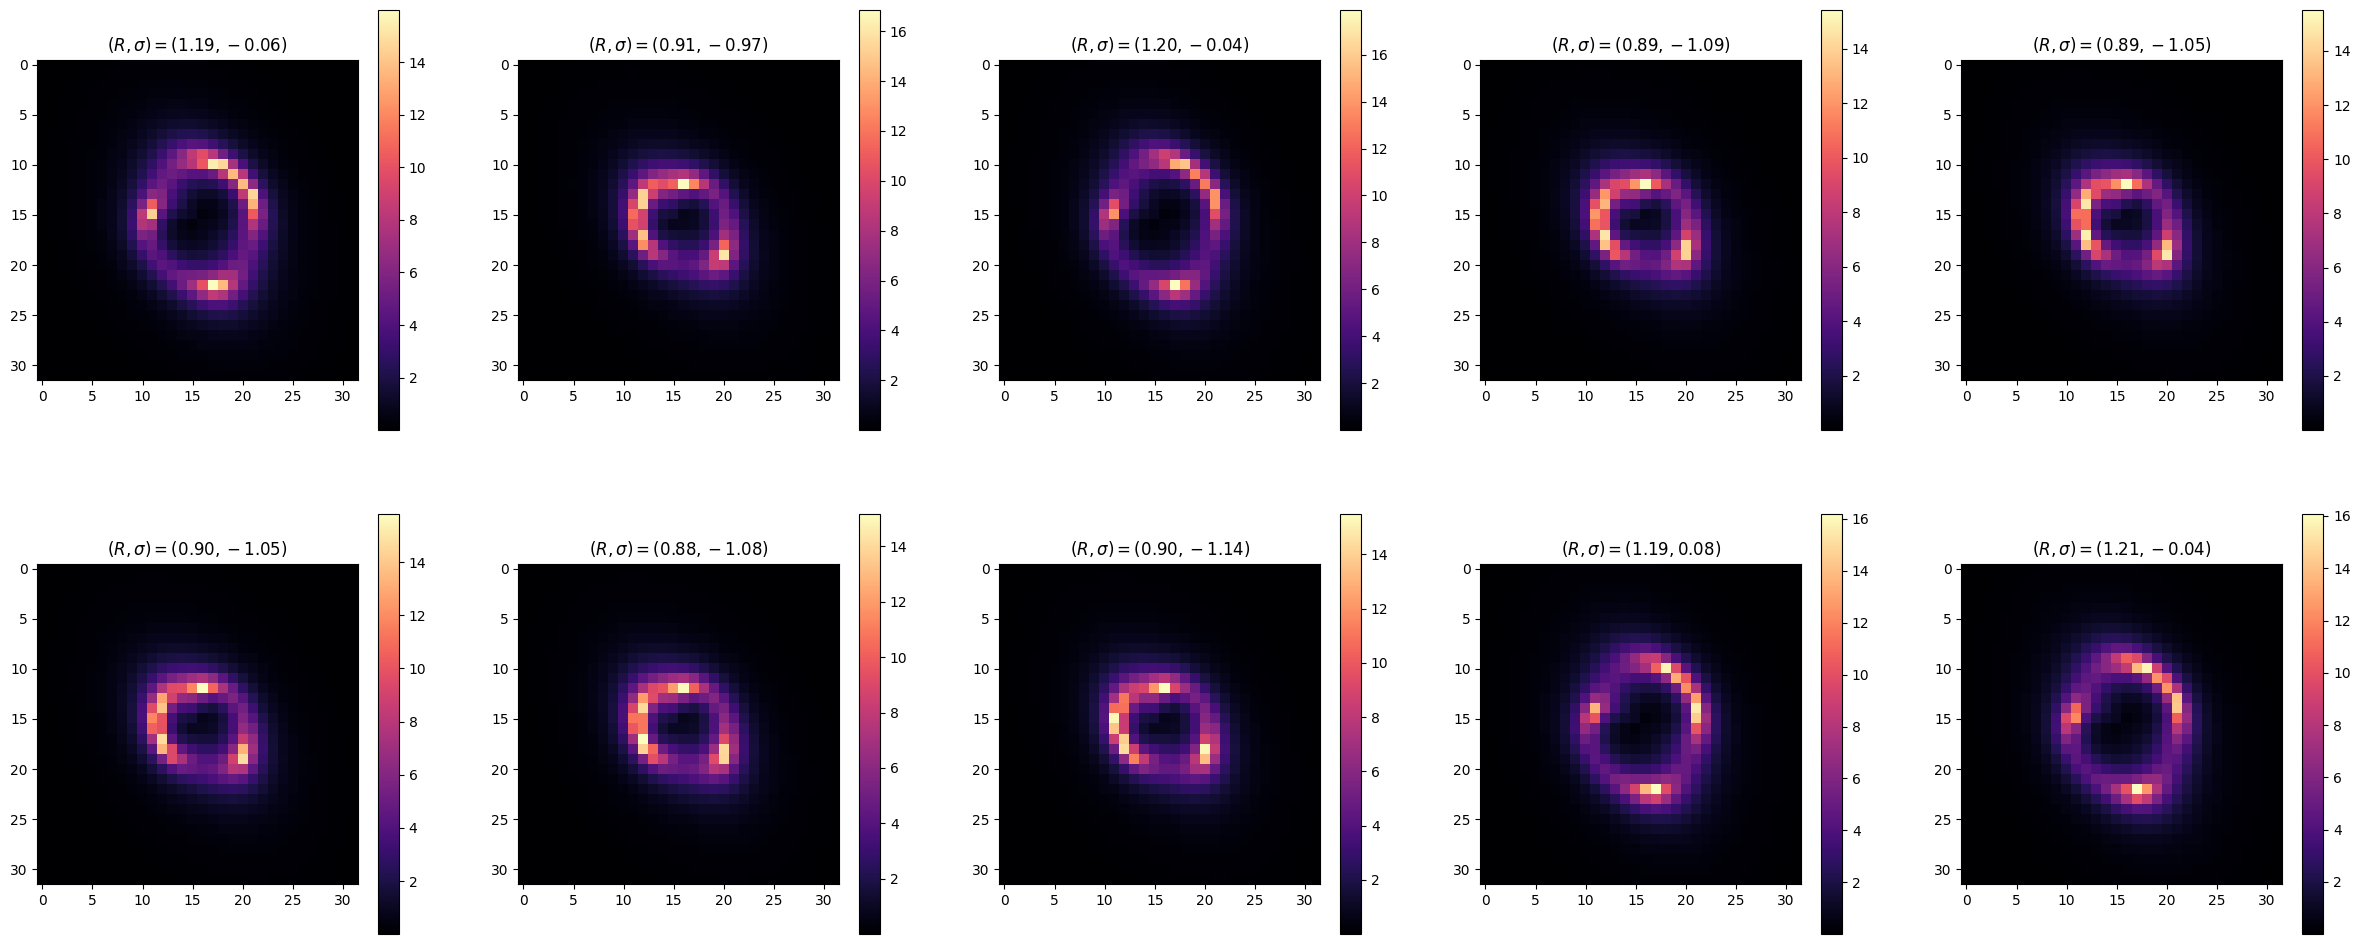

In [14]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 5, figsize = (6 * 5, 6 * 2))

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(images[i], cmap = "magma")
    label = theta[i]
    plt.colorbar(im)
    ax.set(title = r"$(R, \sigma) = (%.2f, %.2f)$"%(label[0], label[1]))

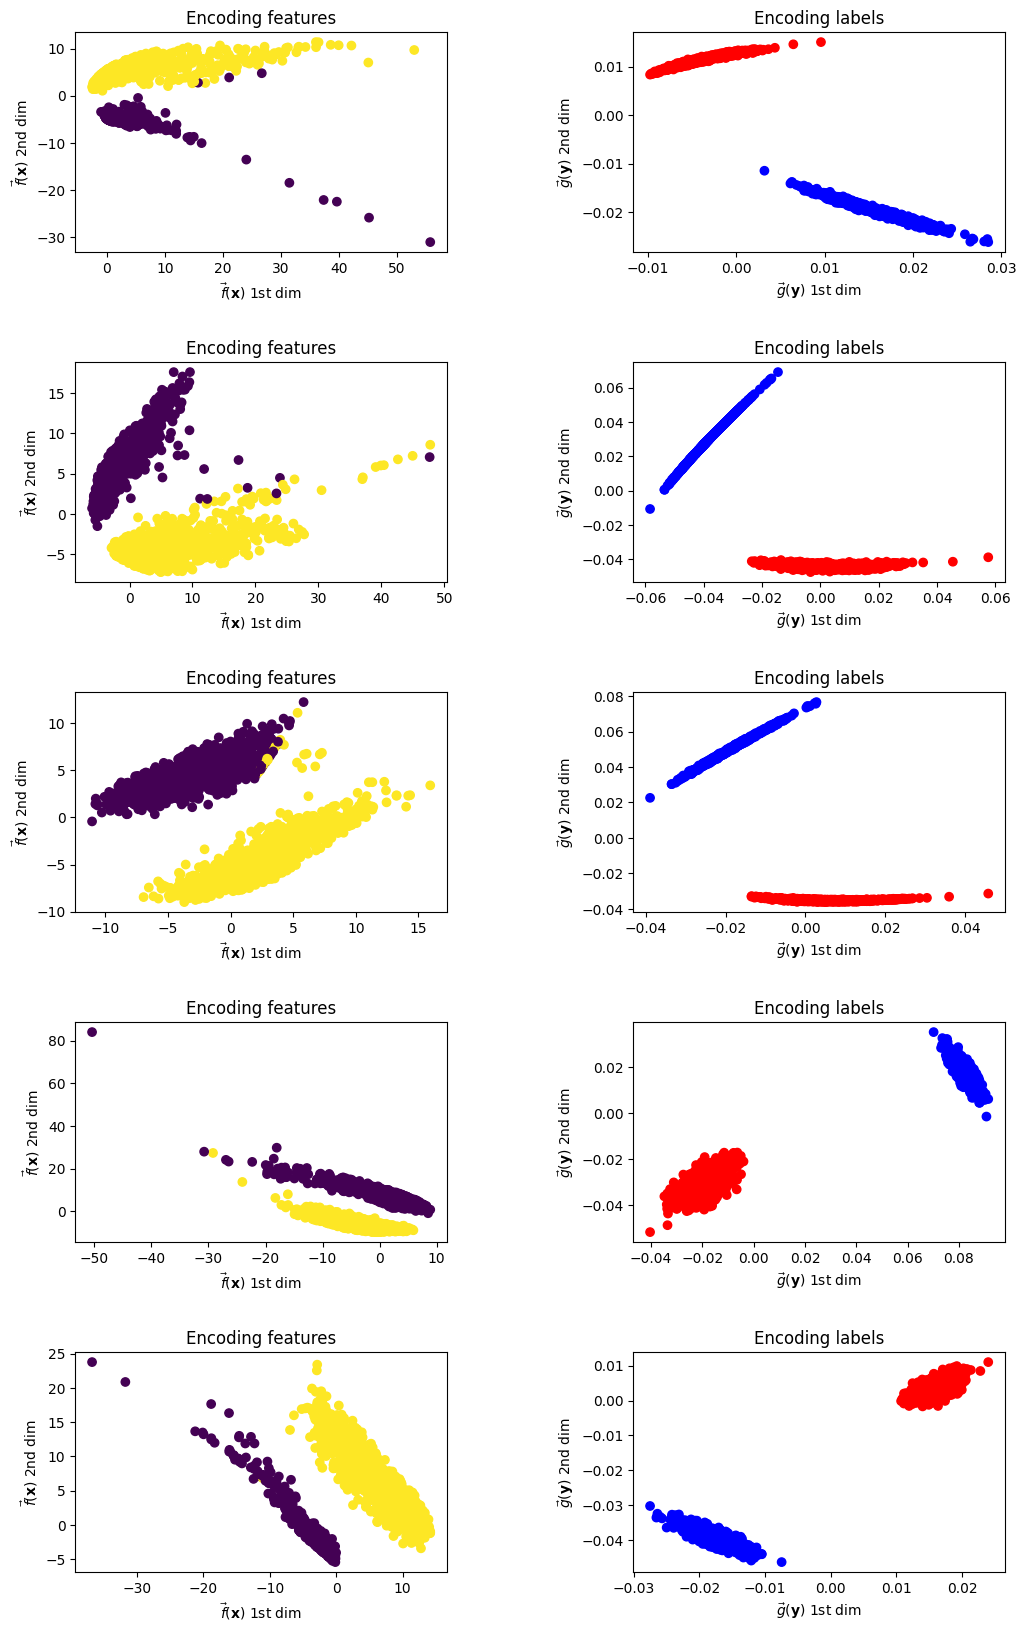

In [15]:
x = images
y = theta


fig, axs = plt.subplots(len(encoder_x_list), 2, figsize = (12, 4 * len(encoder_x_list)))

for i, row_axs in enumerate(axs):
    encoder_x = encoder_x_list[i]
    encoder_y = encoder_y_list[i]
    with torch.no_grad():
        zx = encoder_x(torch.tensor(x).to(torch.float32))
        zy = encoder_y(torch.tensor(y).to(torch.float32))
    ax = row_axs[0]
    
    ax.scatter(*zx.cpu().T, c = labels)
    ax.set(title = "Encoding features", xlabel = r"$\vec{f}(\mathbf{x})$ 1st dim", ylabel = r"$\vec{f}(\mathbf{x})$ 2nd dim")
    ax = row_axs[1]
    ax.scatter(*zy.cpu().T, c = labels, vmin  = 0, vmax = 1, cmap = "bwr")
    ax.set(title = "Encoding labels", xlabel = r"$\vec{g}(\mathbf{y})$ 1st dim", ylabel = r"$\vec{g}(\mathbf{y})$ 2nd dim")


plt.subplots_adjust(wspace = 0.5, hspace = 0.5)

Nice, we observe what we would expect: the two sets of encoded $x$ and $y$ are well separated in latent space. 

## CCA and MCCA
Let's try what Salma did for a single pair of `encoder_features` for now. We will take the 

In [16]:
def plot_CCA_all_latents(dims, scores, models):
    i, j = models[0], models[1]
    plt.figure(figsize=(13,4))
    plt.plot(dims, scores, "o", label="CCA")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA value")
    plt.title("CCA value vs latent dimension for models "+str(i)+" and "+str(j))
    plt.xticks(dims)
    plt.ylim(0,1.05)
    plt.show()
    
def plot_features(z, latent, models):
    latent_label = latent+1
    i, j = models[0], models[1]
    z1, z2 = z[i-1], z[j-1]
    
    # Plot the view in the shared latent space for the desired latent 
    plt.figure(figsize=(6,3))
    plt.title('Correlation between models '+str(i)+' and '+str(j)+' in shared latent space for latent '+str(latent_label))
    plt.scatter(z1[:,latent], z2[:,latent], marker='.')
    plt.xlabel('Feature '+str(latent_label)+' for model '+str(i))
    plt.ylabel('Feature '+str(latent_label)+' for model '+str(j))
    plt.show()

Let's get two models with very similar likelihood score. 

In [18]:
from datasets import load_from_disk 

dset = load_from_disk(f"/home/noedia/scratch/crl/experiments/{EXPERIMENT}/data")
dset = dset.with_format("torch")
nsamples = 5_000

x_set_1 = dset["train"][:nsamples]["image"]
x_set_2 = dset["train"][nsamples:2 * nsamples]["image"]

y_set_1 = dset["train"][:nsamples]["theta"]
y_set_2 = dset["train"][nsamples:2 * nsamples]["theta"]


ndims = 2

In [54]:
from cca_zoo.linear import CCA
encoder_a = encoder_x_list[0]
encoder_b = encoder_x_list[4]

with torch.no_grad():
    model1_samples = encoder_a(x_set_1)
    model2_samples = encoder_b(x_set_1) 

train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(train_views.shape)
dims = np.arange(1,ndims+1)

model = CCA(latent_dimensions=ndims).fit(train_views) 

with torch.no_grad():
    model1_samples = encoder_a(x_set_2)
    model2_samples = encoder_b(x_set_2) 
test_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)

# Canonical correlations on the test data, one value per latent dimension 
corrs = np.abs(model.score(train_views)) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))

(2, 2000, 2)
CCA canonical correlations: [0.87 0.16]


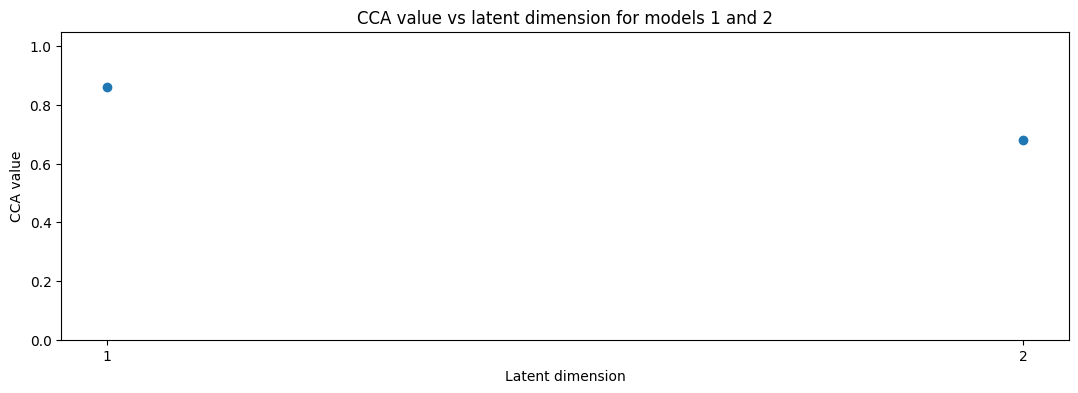

In [29]:
plot_CCA_all_latents(dims, corrs, models=[1,2])

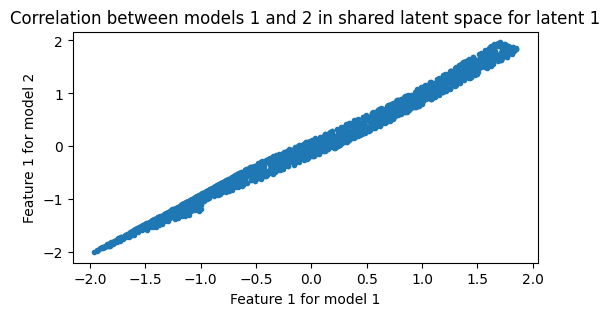

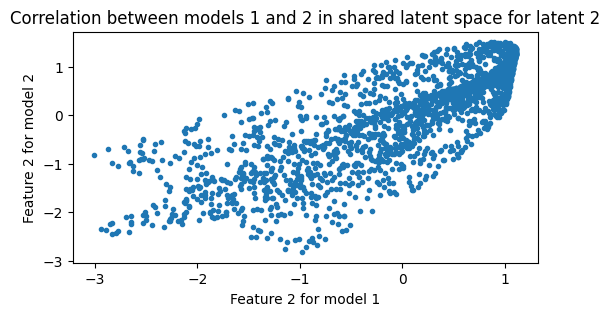

In [42]:
z = model.transform(train_views) 

plot_features(z, 0, models=[1,2])
plot_features(z, 1, models=[1,2])

In [52]:
from cca_zoo.linear import CCA
encoder_a = encoder_y_list[0]
encoder_b = encoder_y_list[2]

with torch.no_grad():
    model1_samples = encoder_a(y_set_1)
    model2_samples = encoder_b(y_set_1) 

train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(train_views.shape)
dims = np.arange(1,ndims+1)

model = CCA(latent_dimensions=ndims).fit(train_views) 

with torch.no_grad():
    model1_samples = encoder_a(y_set_2)
    model2_samples = encoder_b(y_set_2) 
test_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)

# Canonical correlations on the test data, one value per latent dimension 
corrs = np.abs(model.score(test_views)) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))

(2, 2000, 2)
CCA canonical correlations: [0.99 0.92]


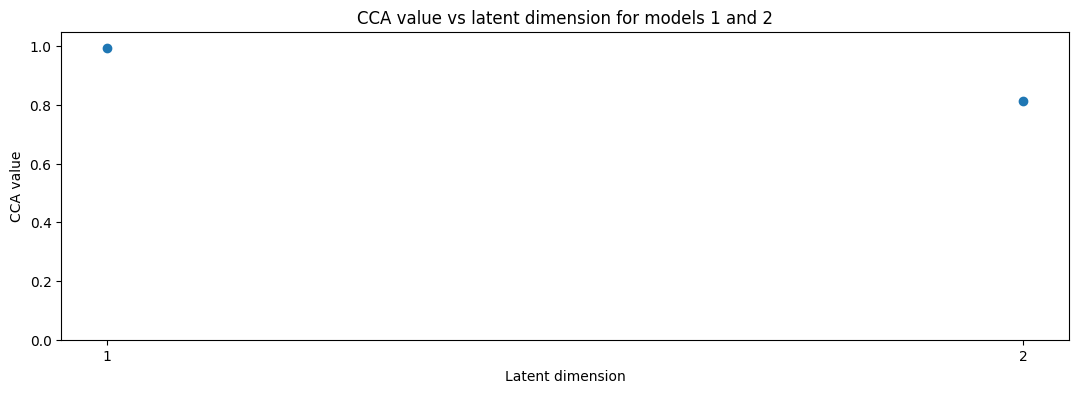

In [32]:
plot_CCA_all_latents(dims, corrs, models=[1,2])

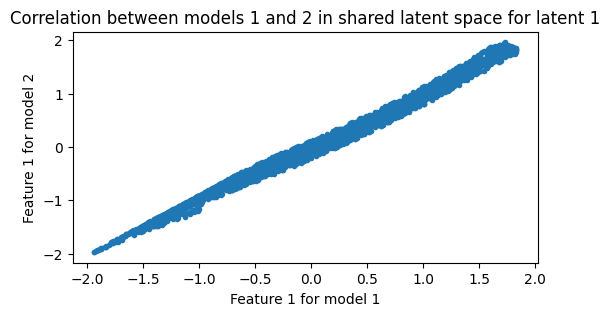

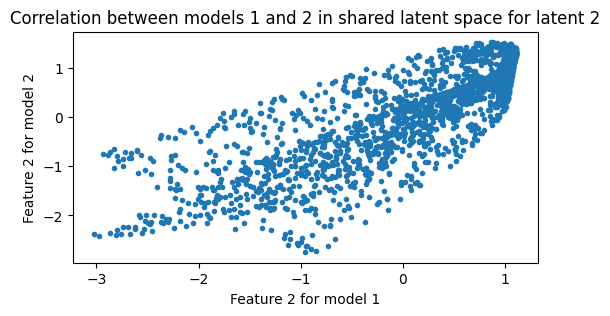

In [33]:
z = model.transform(test_views) 

plot_features(z, 0, models=[1,2])
plot_features(z, 1, models=[1,2])

Checking the MCCA score for all pairs of models

In [39]:
%load_ext autoreload
%autoreload 2
from astro_peek.identifier import CCA_Score

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
model_samples = []

with torch.no_grad(): 
    for encoder in encoder_x_list: 
        model_samples.append(encoder(x_set_1).numpy())
        # encoder = encoder_b(x_set_2)


In [50]:
CCA = CCA_Score(np.array(model_samples))

In [55]:
mcca_score.shape

(5, 5, 2)

In [65]:
mask = ~np.eye(5, dtype = np.bool_)
mcca_score[mask]

array([[0.87069713, 0.69445518],
       [0.78971466, 0.71266334],
       [0.87737681, 0.05198456],
       [0.86642501, 0.17305478],
       [0.87069713, 0.69445518],
       [0.81820617, 0.80248274],
       [0.87663129, 0.37513084],
       [0.856952  , 0.36970102],
       [0.78971466, 0.71266334],
       [0.81820617, 0.80248274],
       [0.83311395, 0.32554746],
       [0.82176983, 0.36419305],
       [0.87737681, 0.05198456],
       [0.87663129, 0.37513084],
       [0.83311395, 0.32554746],
       [0.94913559, 0.89663423],
       [0.86642501, 0.17305478],
       [0.856952  , 0.36970102],
       [0.82176983, 0.36419305],
       [0.94913559, 0.89663423]])

In [67]:
mcca_score[0, 1]

array([0.87069713, 0.69445518])

In [68]:
mcca_score[1, 0]

array([0.87069713, 0.69445518])

In [82]:
from itertools import combinations 

possible_pairs_idx = combinations(np.arange(len(encoder_x_list)), r = 2)

scores = []
for possible_pair in possible_pairs_idx:
    scores.append(mcca_score[possible_pair])
scores = np.array(scores)
mean_score = np.mean(scores, axis = 0)

In [83]:
scores

array([[0.87069713, 0.69445518],
       [0.78971466, 0.71266334],
       [0.87737681, 0.05198456],
       [0.86642501, 0.17305478],
       [0.81820617, 0.80248274],
       [0.87663129, 0.37513084],
       [0.856952  , 0.36970102],
       [0.83311395, 0.32554746],
       [0.82176983, 0.36419305],
       [0.94913559, 0.89663423]])

In [84]:
mean_score

array([0.85600224, 0.47658472])

In [73]:
possible_pairs_idx

In [ ]:
scores = mcca_score[mask]
scores.shape 

In [61]:
mask

array([[False,  True,  True,  True,  True],
       [ True, False,  True,  True,  True],
       [ True,  True, False,  True,  True],
       [ True,  True,  True, False,  True],
       [ True,  True,  True,  True, False]])

array([[0.87069713, 0.69445518],
       [0.78971466, 0.71266334],
       [0.87737681, 0.05198456],
       [0.86642501, 0.17305478],
       [0.87069713, 0.69445518],
       [0.81820617, 0.80248274],
       [0.87663129, 0.37513084],
       [0.856952  , 0.36970102],
       [0.78971466, 0.71266334],
       [0.81820617, 0.80248274],
       [0.83311395, 0.32554746],
       [0.82176983, 0.36419305],
       [0.87737681, 0.05198456],
       [0.87663129, 0.37513084],
       [0.83311395, 0.32554746],
       [0.94913559, 0.89663423],
       [0.86642501, 0.17305478],
       [0.856952  , 0.36970102],
       [0.82176983, 0.36419305],
       [0.94913559, 0.89663423]])

In [51]:
mcca_score = CCA.compute_all_pairwise_cca()
mask = np.
print(mcca_score)

[[[1.         1.        ]
  [0.87069713 0.69445518]
  [0.78971466 0.71266334]
  [0.87737681 0.05198456]
  [0.86642501 0.17305478]]

 [[0.87069713 0.69445518]
  [1.         1.        ]
  [0.81820617 0.80248274]
  [0.87663129 0.37513084]
  [0.856952   0.36970102]]

 [[0.78971466 0.71266334]
  [0.81820617 0.80248274]
  [1.         1.        ]
  [0.83311395 0.32554746]
  [0.82176983 0.36419305]]

 [[0.87737681 0.05198456]
  [0.87663129 0.37513084]
  [0.83311395 0.32554746]
  [1.         1.        ]
  [0.94913559 0.89663423]]

 [[0.86642501 0.17305478]
  [0.856952   0.36970102]
  [0.82176983 0.36419305]
  [0.94913559 0.89663423]
  [1.         1.        ]]]


Fitting a matrix and visualizing the latent space. 

## $R^2$ score

In [17]:


encoder_x_list = []

model_list = []
print("Loading the models for different random seeds ")
for path in tqdm(encoder_x_paths): 
    model_data = torch.load(path, map_location = "cpu")

In [18]:
model_data.keys()

dict_keys(['model', 'model_cfg', 'seed'])

['/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_47_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_38_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_40_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_42_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_45_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_43_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_44_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_37_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_46_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_39_latentdim_2.pt',


In [12]:
model_path + encoders_features_dir + pattern

'/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/*.pt'